<a href="https://colab.research.google.com/github/siva893/Crime-Prediction-/blob/main/Crime_Multiclassification_tranfer_learning1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wget
!pip install gensim
!pip install psutil
!pip install spacy
!pip install --pre dgl -f https://data.dgl.ai/wheels/cu116/repo.html
!pip install --pre dglgo -f https://data.dgl.ai/wheels-test/repo.html
!pip install -U sentence-transformers
!pip install keras


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=be10115edca169afeb5ec12fcaa441178a6f5e7e1914f0b8e24ff9d3993ca15e
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget
Looking in links: https://data.dgl.ai/wheels/cu116/repo.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.8 MB/s eta 0:00:00
Looking in links: https://data.dgl.ai/wheels-test/repo.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
import io
import pandas as pd
import nltk
import re
import string
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import numpy as np
from nltk.tokenize import TweetTokenizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

In [ ]:
df1=pd.read_excel('/content/Categorized_Crime_.xlsx',sheet_name='Sheet1')

In [ ]:
df1.shape

(200, 2)

In [ ]:
df1.head()

,Description,Label
0,The U.N. organization assisting in investigati...,crime
1,RG Kar Rape Case: The body of the trainee doct...,assault
2,The IT hub of India faces a strange kind of pr...,crime
3,Police in California released a video of a tri...,crime
4,Crime Officer fatally shot in a North Carolina...,crime


In [ ]:
df1['Label'].value_counts()

,count
Label,
crime,120
general crime,38
murder,14
assault,8
violence,8
arson,4
corruption,2
robbery,2
drug crime,2


In [ ]:
df1['Label'].nunique()

10

In [ ]:
crime_types = []
for _,j in df1.iterrows():
  if j['Label'] == 'crime':
    crime_types.append(0)
  elif j['Label'] == 'general crime':
    crime_types.append(1)
  elif j['Label'] == 'murder':
    crime_types.append(2)
  elif j['Label'] == 'assault':
    crime_types.append(3)
  elif j['Label'] == 'violence':
    crime_types.append(4)
  elif j['Label'] == 'arson':
    crime_types.append(5)

  elif j['Label'] == 'corruption':
    crime_types.append(6)

  elif j['Label'] == 'robbery':
    crime_types.append(7)
  elif j['Label'] == 'drug crime':
    crime_types.append(8)

  else:
    crime_types.append(9)

In [ ]:
df1['crime_types'] = crime_types
df1

,Description,Label,crime_types
0,The U.N. organization assisting in investigati...,crime,0
1,RG Kar Rape Case: The body of the trainee doct...,assault,3
2,The IT hub of India faces a strange kind of pr...,crime,0
3,Police in California released a video of a tri...,crime,0
4,Crime Officer fatally shot in a North Carolina...,crime,0
...,...,...,...
195,"""One of the most depraved crimes one person co...",crime,0
196,"Warwickshire's Police and Crime Commissioner, ...",crime,0
197,Jeremy Craddock's new book explores a notoriou...,murder,2
198,A man has been arrested in New York in connect...,crime,0


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df1['transformed_tweet'] = df1['Description'].apply(lambda x: re.sub(r'^RT[\s]+', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'@[\w]*', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'https?:\/\/.*[\r\n]*', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'#', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'[0-9]', '', x))


In [ ]:
df1.head()

,Description,Label,crime_types,transformed_tweet
0,The U.N. organization assisting in investigati...,crime,0,The U.N. organization assisting in investigati...
1,RG Kar Rape Case: The body of the trainee doct...,assault,3,RG Kar Rape Case: The body of the trainee doct...
2,The IT hub of India faces a strange kind of pr...,crime,0,The IT hub of India faces a strange kind of pr...
3,Police in California released a video of a tri...,crime,0,Police in California released a video of a tri...
4,Crime Officer fatally shot in a North Carolina...,crime,0,Crime Officer fatally shot in a North Carolina...


In [ ]:
df1.to_csv('crime_data1.csv',index=False)

NameError: name 'df1' is not defined

In [ ]:
df1=pd.read_csv('/content/crime_data1.csv')

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove*.zip

--2025-02-18 16:14:32--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-02-18 16:14:32--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-02-18 16:14:32--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df1['transformed_tweet'].fillna('')
y = df1['crime_types']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
max_vocab_size = 5000
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [ ]:
import numpy as np

embedding_dim = 100
glove_path = 'glove.6B.100d.txt'

embeddings_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefficients = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefficients

print(f"Loaded {len(embeddings_index)} word vectors.")


vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")



Loaded 400000 word vectors.
Embedding matrix shape: (1355, 100)


In [ ]:

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_sequence_length = 100
X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post', truncating='post')


In [ ]:
num_classes=10

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_sequence_length,
              trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32
)

test_loss, test_accuracy = model.evaluate(X_test_padded, y_test)
print(f"Test Accuracy with Pre-trained Embeddings: {test_accuracy:.2f}")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.3012 - loss: 2.1421 - val_accuracy: 0.7000 - val_loss: 0.9809
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5775 - loss: 1.3302 - val_accuracy: 0.7000 - val_loss: 0.8163
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6698 - loss: 1.0119 - val_accuracy: 0.8750 - val_loss: 0.8434
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8082 - loss: 0.7942 - val_accuracy: 0.7500 - val_loss: 0.7062
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8147 - loss: 0.6285 - val_accuracy: 0.8250 - val_loss: 0.5945
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9084 - loss: 0.4249 - val_accuracy: 0.9500 - val_loss: 0.5370
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9741 - loss: 0.3141 - val_accuracy: 0.9500 - val_loss: 0.4715
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.2036 - val_accuracy: 0.9500 - val_loss: 0.4061

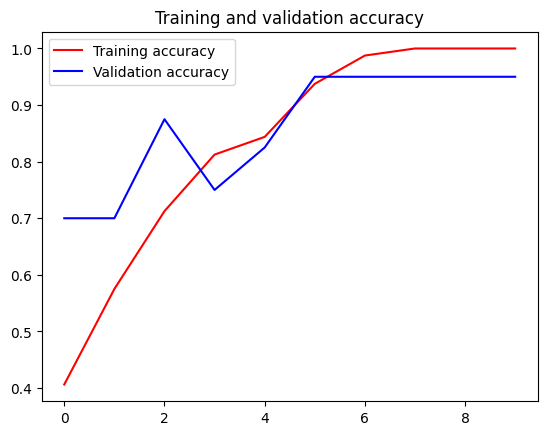

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

plt.show()

### Identifying crime Hotspots

In [ ]:
import pandas as pd
df=pd.read_excel('/content/processed_crime_dataset.xlsx',sheet_name='Sheet1')

In [ ]:
df.shape

(500, 31)

In [ ]:
df.head()

,Crime ID,Crime Type,Crime Description,Severity Level,Date & Time,Day of the Week,Season,Latitude,Longitude,Street Name,...,Arrests Made,Previous Crime History,Weather Conditions,Lighting Conditions,CCTV Presence,Victim Age,Victim Gender,Offender Age,Offender Gender,Relationship Between Victim & Offender
0,CRIME-00001,Assault,Reported assault in the area.,Minor,2024-10-21 17:39:41,Monday,Fall,33.9832,-118.2652,600 E 62ND ST,...,No,No,Rainy,Well-lit,Yes,24,Male,57,Other,Acquaintance
1,CRIME-00002,Drug Offense,Reported drug offense in the area.,Major,2022-03-27 20:54:56,Sunday,Winter,34.2440,-118.5583,9300 TAMPA AV,...,No,No,Foggy,Poorly-lit,No,38,Other,57,Male,Unknown
2,CRIME-00003,Burglary,Reported burglary in the area.,Severe,2023-05-25 18:01:07,Thursday,Summer,34.1915,-118.5843,6500 WINNETKA AV,...,No,Yes,Rainy,Poorly-lit,Yes,29,Female,52,Male,Stranger
3,CRIME-00004,Fraud,Reported fraud in the area.,Minor,2022-08-04 15:53:37,Thursday,Spring,34.0109,-118.2964,1200 W MARTIN LUTHER KING JR BL,...,Yes,No,Snowy,Well-lit,Yes,66,Other,43,Female,Unknown
4,CRIME-00005,Vandalism,Reported vandalism in the area.,Severe,2024-08-10 08:55:45,Saturday,Winter,34.1732,-118.6152,5900 TOPANGA CANYON BL,...,No,No,Clear,Well-lit,No,74,Female,22,Female,Family


In [ ]:
df.columns

Index(['Crime ID', 'Crime Type', 'Crime Description', 'Severity Level',
       'Date & Time', 'Day of the Week', 'Season', 'Latitude', 'Longitude',
       'Street Name', 'Neighborhood', 'City', 'State', 'Type of Area',
       'Nearby Landmarks', 'Population Density', 'Income Level',
       'Unemployment Rate', 'Education Level', 'Police Response Time',
       'Number of Officers Deployed', 'Arrests Made', 'Previous Crime History',
       'Weather Conditions', 'Lighting Conditions', 'CCTV Presence',
       'Victim Age', 'Victim Gender', 'Offender Age', 'Offender Gender',
       'Relationship Between Victim & Offender'],
      dtype='object')

In [ ]:
cat_cols = [cols for cols in df.columns if df[cols].dtype == 'object']

In [ ]:
for col in cat_cols:
    if df[col].apply(lambda x: isinstance(x, list)).any():
        print(f"Column '{col}' contains lists.")

In [ ]:
df.describe(include='object')

,Crime ID,Crime Type,Crime Description,Severity Level,Day of the Week,Season,Street Name,Neighborhood,City,State,...,Education Level,Arrests Made,Previous Crime History,Weather Conditions,Lighting Conditions,CCTV Presence,Victim Gender,Offender Gender,Relationship Between Victim & Offender,cordinates
count,500,500,500,500,500,500,500,500,500,500,...,500,500,500,500,500,500,500,500,500,500
unique,500,7,7,3,7,4,487,50,21,1,...,3,2,2,4,2,2,3,3,4,491
top,CRIME-00001,Homicide,Reported homicide in the area.,Major,Saturday,Spring,6200 HOLLYWOOD BL,Neighborhood 41,N Hollywood,CA,...,High,No,No,Snowy,Poorly-lit,Yes,Female,Male,Unknown,"[34.1016, -118.3252]"
freq,1,87,87,177,92,130,3,18,37,500,...,180,250,267,141,251,269,172,170,135,2


In [ ]:
print(cat_cols)

['Crime ID', 'Crime Type', 'Crime Description', 'Severity Level', 'Day of the Week', 'Season', 'Street Name', 'Neighborhood', 'City', 'State', 'Type of Area', 'Nearby Landmarks', 'Education Level', 'Arrests Made', 'Previous Crime History', 'Weather Conditions', 'Lighting Conditions', 'CCTV Presence', 'Victim Gender', 'Offender Gender', 'Relationship Between Victim & Offender', 'cordinates']


In [ ]:
#categorical_cols = cat_cols
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
df_encoded.head(2)

,Date & Time,Latitude,Longitude,Population Density,Income Level,Unemployment Rate,Police Response Time,Number of Officers Deployed,Victim Age,Offender Age,...,Weather Conditions_Snowy,Lighting Conditions_Well-lit,CCTV Presence_Yes,Victim Gender_Male,Victim Gender_Other,Offender Gender_Male,Offender Gender_Other,Relationship Between Victim & Offender_Family,Relationship Between Victim & Offender_Stranger,Relationship Between Victim & Offender_Unknown
0,2024-10-21 17:39:41,33.9832,-118.2652,2793,50302,9.07,12,9,24,57,...,False,True,True,True,False,False,True,False,False,False
1,2022-03-27 20:54:56,34.2440,-118.5583,2422,71113,8.64,10,6,38,57,...,False,False,False,False,True,True,False,False,False,True


In [ ]:

X = df_encoded

In [ ]:
df_encoded["Timestamp"] = df_encoded["Date & Time"].astype(int) / 10**9  # Convert to seconds

# Drop the original "Date & Time" column
df_encoded.drop(columns=["Date & Time"], inplace=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

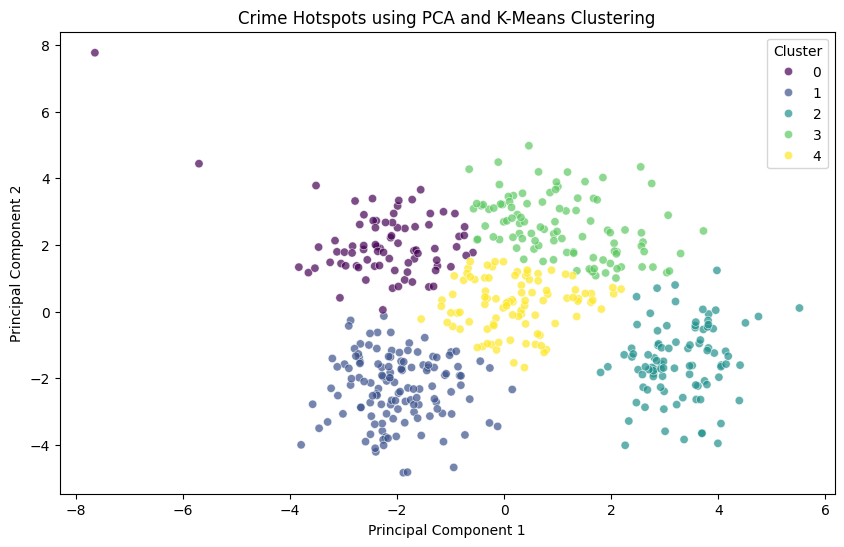

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df_pca['Cluster'] = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['Cluster'], palette='viridis', alpha=0.7)
plt.title("Crime Hotspots using PCA and K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### predictive Modelling

In [ ]:
inertia = []
k_values = range(1, 10)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords_scaled)
    inertia.append(kmeans.inertia_)



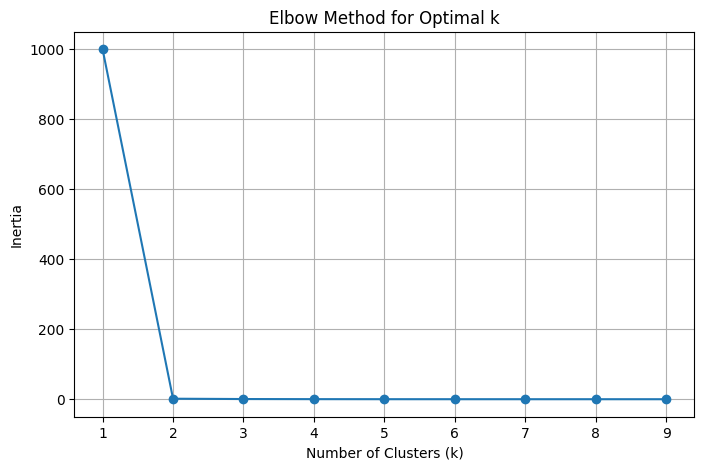

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o", linestyle="-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(coords_scaled)

In [ ]:
# Define features and target
features = [
    "Population Density", "Income Level", "Unemployment Rate", "Police Response Time",
    "Number of Officers Deployed", "Weather Conditions", "Lighting Conditions", "CCTV Presence",
    "Day of the Week", "Season", "Type of Area"
]
target = "KMeans_Cluster"


In [ ]:

df_encoded = df.copy()
label_encoders = {}
for col in features:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

In [ ]:
df["KMeans_Cluster"].nunique()

2

In [ ]:
X = df_encoded[features]
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [ ]:
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)


Model Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Predictive Modelling using XG-boost classifier

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(objective="multi:softmax", num_class=optimal_k, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:52:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=2, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [ ]:
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

